In [6]:
import pandas as pd
df = pd.read_csv('/content/Steel_industry_data.csv')

# Remove unwanted spaces in column names
df.columns= df.columns.str.strip()
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
# Sort by time (important for time-series)
df = df.sort_values (by='date')
# Remove duplicate rows
df = df.drop_duplicates()
# Check missing values
print("Missing values: \n", df.isnull().sum())
# If any missing values remove (safe)
df = df.dropna()
# Fix column name case for consistency with later cells
df.rename(columns={'Usage_kWh': 'Usage_kwh'}, inplace=True)
# Final check
print("\nDataset shape:", df.shape)
df.head()

Missing values: 
 date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64

Dataset shape: (35040, 11)


,date,Usage_kwh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
95,2018-01-01 00:00:00,3.42,3.46,0.0,0.0,70.30,100.0,0,Weekday,Monday,Light_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load


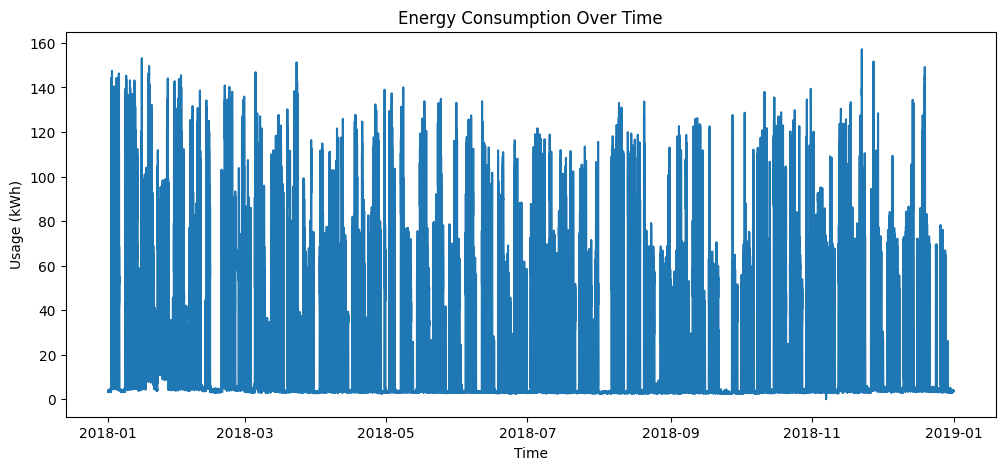

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['Usage_kwh'])
plt.title("Energy Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Usage (kWh)")
plt.show()

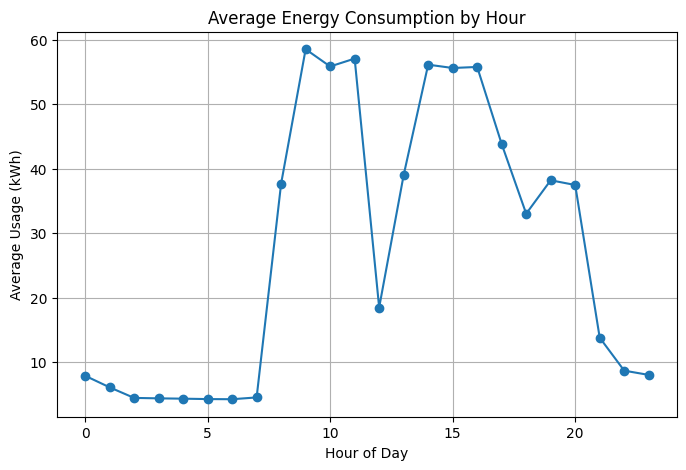

In [8]:
df['hour'] = df['date'].dt.hour
hourly_avg = df.groupby('hour') ['Usage_kwh'].mean()
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
hourly_avg.plot(kind='line', marker='o')
plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Usage (kWh)")
plt.grid()
plt.show()

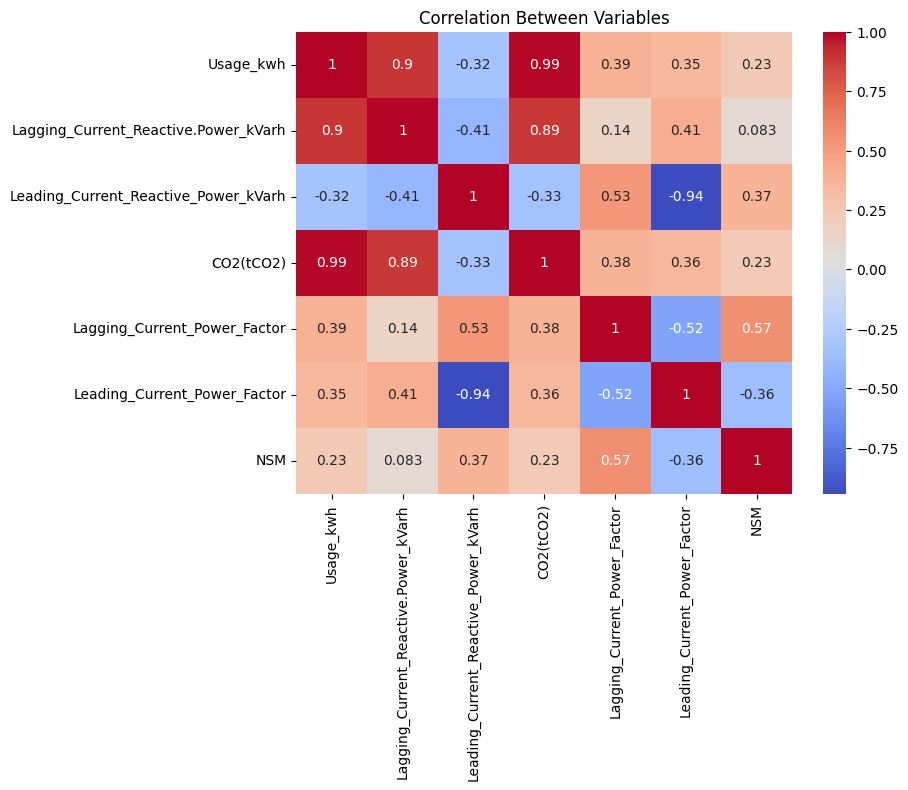

In [9]:
numeric_df = df.select_dtypes (include=['float64', 'int64'])
corr = numeric_df.corr()
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize = (8, 6) )
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Variables")
plt.show()

In [10]:
# Find peak load
peak_row = df.loc[df['Usage_kwh'].idxmax()]
print("Peak Load Details:\n")
print(peak_row)

Peak Load Details:

date                                    2018-11-22 09:45:00
Usage_kwh                                            157.18
Lagging_Current_Reactive.Power_kVarh                  77.72
Leading_Current_Reactive_Power_kVarh                    0.0
CO2(tCO2)                                              0.07
Lagging_Current_Power_Factor                          89.64
Leading_Current_Power_Factor                          100.0
NSM                                                   35100
WeekStatus                                          Weekday
Day_of_week                                        Thursday
Load_Type                                       Medium_Load
hour                                                      9
Name: 31238, dtype: object


In [11]:
week_analysis = df.groupby ('WeekStatus') ['Usage_kwh'].mean()
print(week_analysis)

WeekStatus
Weekday    33.624727
Weekend    11.732327
Name: Usage_kwh, dtype: float64


<Axes: title={'center': 'Weekday vs Weekend Energy Usage'}, xlabel='WeekStatus'>

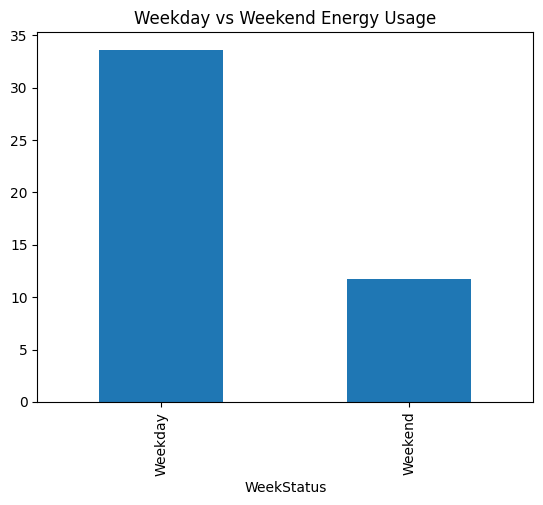

In [12]:
week_analysis.plot(kind='bar', title="Weekday vs Weekend Energy Usage")

In [13]:
load_analysis = df.groupby('Load_Type') ['Usage_kwh'].mean()
print(load_analysis)

Load_Type
Light_Load       8.626207
Maximum_Load    59.265314
Medium_Load     38.445394
Name: Usage_kwh, dtype: float64


<Axes: title={'center': 'Energy Usage by Load Type'}, xlabel='Load_Type'>

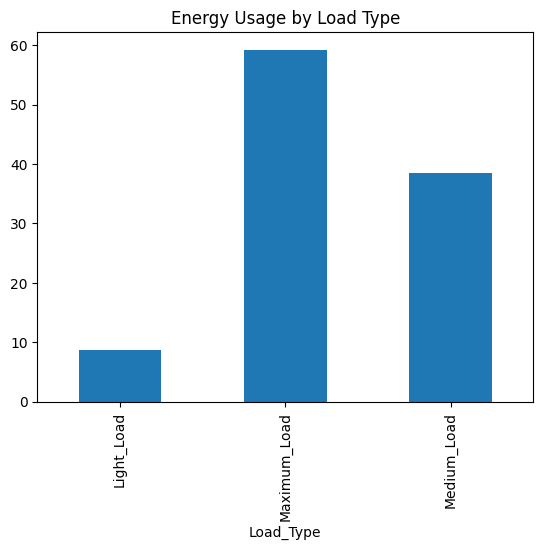

In [14]:
load_analysis.plot(kind='bar', title="Energy Usage by Load Type")

In [15]:
df [['Usage_kwh', 'Lagging_Current_Power_Factor']].corr()

,Usage_kwh,Lagging_Current_Power_Factor
Usage_kwh,1.00000,0.38596
Lagging_Current_Power_Factor,0.38596,1.00000


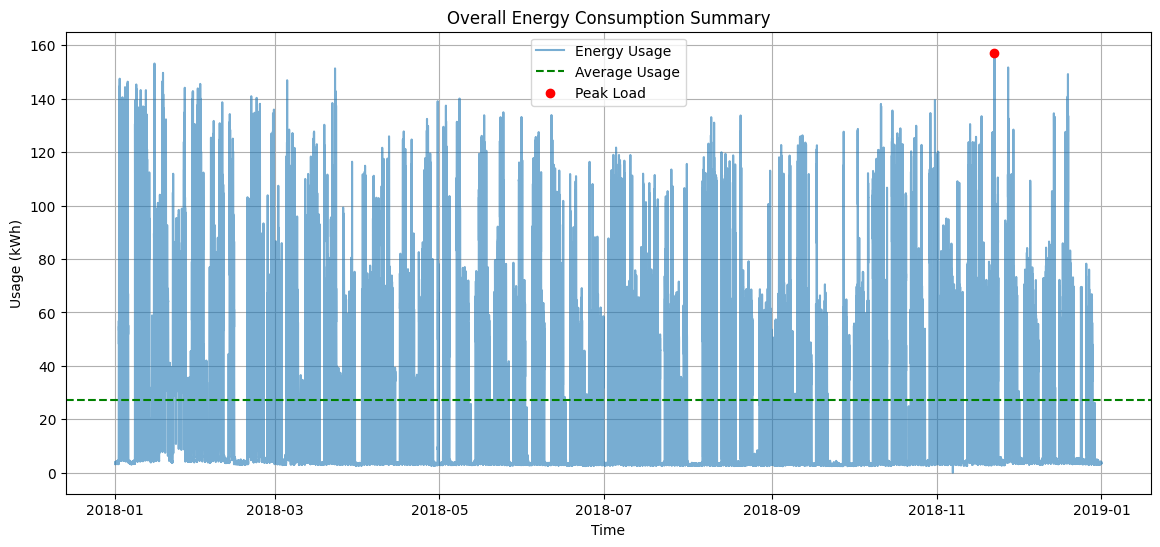

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
# Plot energy usage
plt.plot(df['date'], df['Usage_kwh'], label='Energy Usage', alpha=0.6)
# Average line
avg_usage = df ['Usage_kwh'].mean()
plt.axhline(avg_usage, color='green', linestyle='--', label='Average Usage')
# Peak point
peak_idx = df ['Usage_kwh'].idxmax()
plt.scatter(df.loc[peak_idx, 'date'], df.loc[peak_idx, 'Usage_kwh'], color='red', label='Peak Load', zorder=5)
plt.title("Overall Energy Consumption Summary")
plt.xlabel("Time")
plt.ylabel("Usage (kWh)")
plt.legend()
plt.grid()
plt.show()

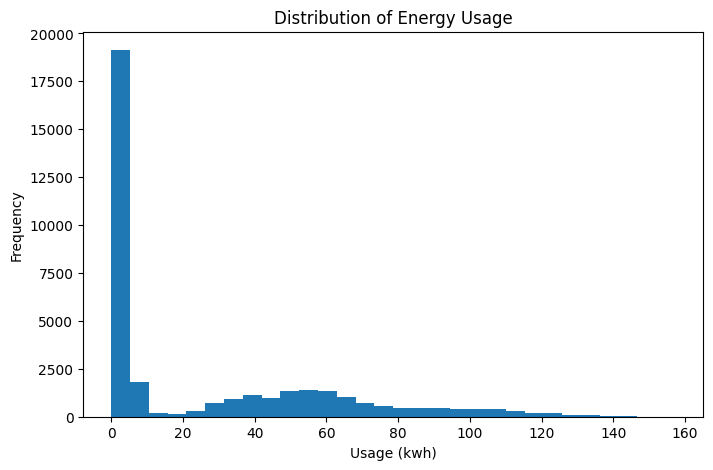

In [19]:
plt.figure(figsize=(8,5))
plt.hist(df['Usage_kwh'], bins=30)
plt.title("Distribution of Energy Usage")
plt.xlabel("Usage (kwh)")
plt.ylabel("Frequency")
plt.show()